In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

from keras.models import Sequential
from keras.layers import Dense, MaxPooling2D, Conv2D, UpSampling2D
from sklearn.model_selection import train_test_split

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

In [3]:
X[0].shape

(784,)

In [4]:
dummy=X[0].reshape(28, 28)

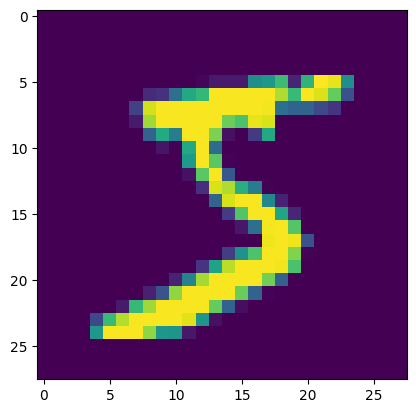

In [5]:
plt.imshow(dummy)
plt.show()

C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2909032302.py:9: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2909032302.py:10: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2909032302.py:11: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


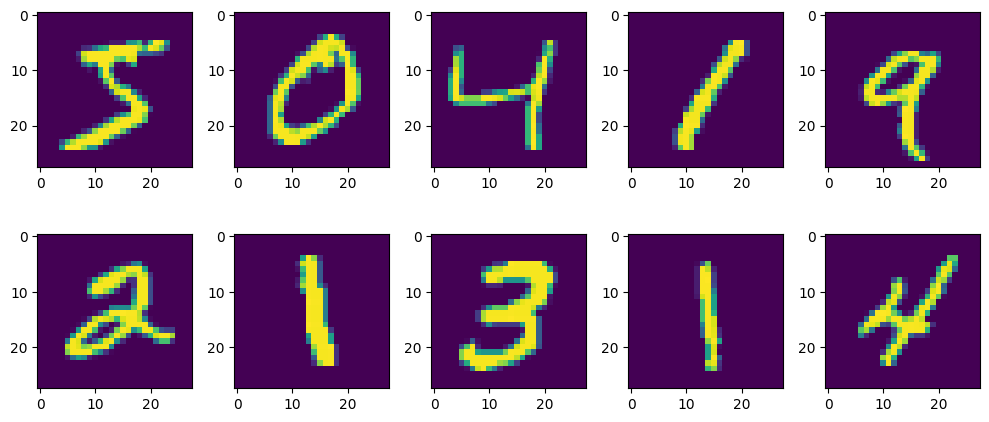

In [6]:
start=0
fig, axs=plt.subplots(2, 5, figsize=(10, 10))
for i in range(2):
  for j in range(5):
    dummy=X[start].reshape(28, 28)
    axs[i][j].imshow(dummy)
    start += 1
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train=X_train.astype('float32')/255
X_test=X_test.astype('float32')/255

In [9]:
X_train.max(), X_train.min()
# SO our data is normalized now

(1.0, 0.0)

In [10]:
X_train=X_train.reshape(len(X_train), 28, 28, 1)
X_test=X_test.reshape(len(X_test), 28, 28, 1)

In [11]:
X_train[0].shape, X_test[0].shape

((28, 28, 1), (28, 28, 1))

In [12]:
X_train.shape, X_test.shape

((56000, 28, 28, 1), (14000, 28, 28, 1))

In [13]:
# As MNIST doo not have the original, Denoised image, so we have to add some noise from oursize to make the input
noise_factor=0.2
X_train_noisy= X_train+noise_factor*np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy= X_test+noise_factor*np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2346502885.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2346502885.py:6: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2346502885.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2346502885.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2346502885.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2346502885.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\2346502885.py:16: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


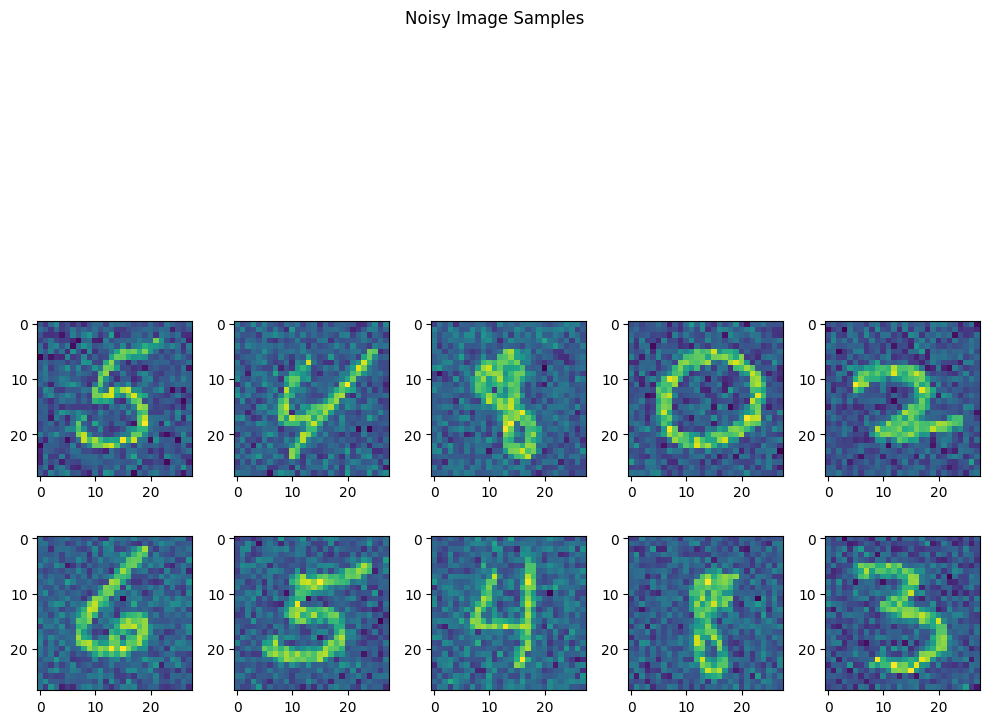

In [14]:
start=0
fig, axs=plt.subplots(2, 5, figsize=(10, 10))
fig.suptitle('Noisy Image Samples')
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
for i in range(2):
  for j in range(5):
    dummy=X_train_noisy[start].reshape(28, 28)
    axs[i][j].imshow(dummy)
    start += 1
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()

plt.show()

In [15]:
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

C:\Users\maila\AppData\Local\Temp\ipykernel_28696\3735930128.py:5: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\3735930128.py:6: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\3735930128.py:7: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\3735930128.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\3735930128.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\3735930128.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\3735930128.py:16: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


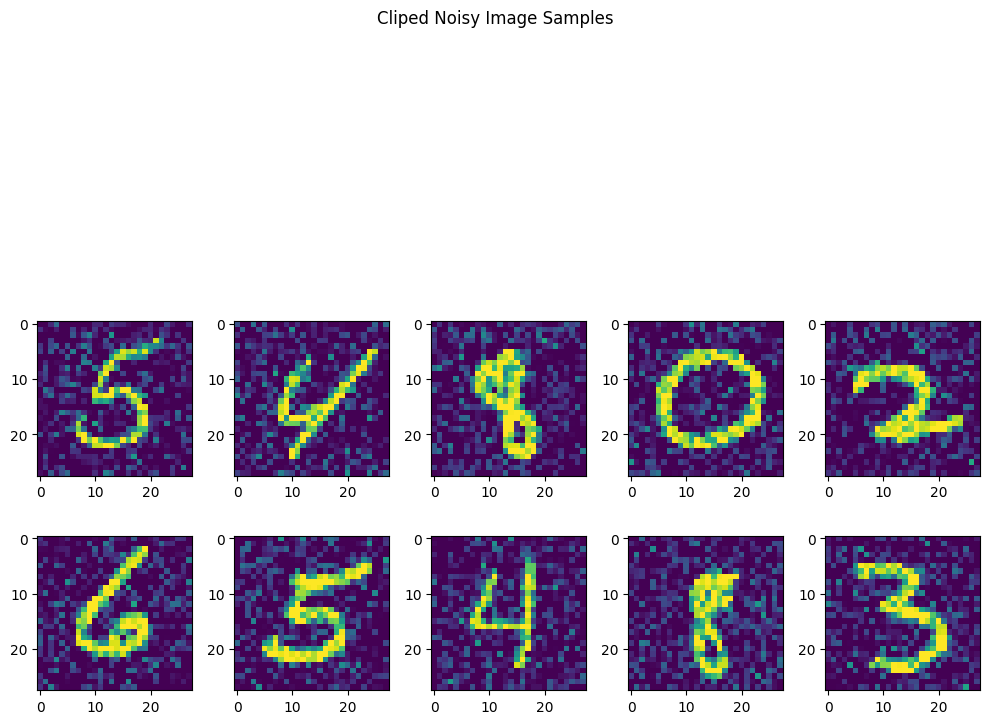

In [16]:
start=0
fig, axs=plt.subplots(2, 5, figsize=(10, 10))
fig.suptitle('Cliped Noisy Image Samples')
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
for i in range(2):
  for j in range(5):
    dummy=X_train_noisy[start].reshape(28, 28)
    axs[i][j].imshow(dummy)
    start += 1
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()

plt.show()

## Model Building

In [19]:
import tensorflow
early_stopping = tensorflow.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

In [20]:
model=Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))
#model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))

#model.add(MaxPooling2D((2, 2), padding='same'))

model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
# model.add(UpSampling2D((2, 2)))
model.add(Conv2D(1, (3, 3), activation='relu', padding='same'))

c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         2,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,425 (25.10 KB)

 Trainable params: 6,425 (25.10 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer='adam', metrics=['mae'], loss='mean_squared_error')

In [23]:
history=model.fit(X_train_noisy, X_train, epochs=100, validation_data=(X_test_noisy, X_test),  callbacks=[early_stopping])

Epoch 1/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0115 - mae: 0.0377 - val_loss: 0.0069 - val_mae: 0.0271
Epoch 2/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - loss: 0.0062 - mae: 0.0256 - val_loss: 0.0057 - val_mae: 0.0242
Epoch 3/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - loss: 0.0054 - mae: 0.0235 - val_loss: 0.0052 - val_mae: 0.0228
Epoch 4/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - loss: 0.0051 - mae: 0.0226 - val_loss: 0.0049 - val_mae: 0.0219
Epoch 5/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - loss: 0.0049 - mae: 0.0220 - val_loss: 0.0047 - val_mae: 0.0216
Epoch 6/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 57s 33ms/step - loss: 0.0047 - mae: 0.0217 - val_loss: 0.0046 - val_mae: 0.0213
Epoch 7/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 84s 34ms/step - loss: 0.0046 - mae: 0.0214 - val_loss: 0.0046 - val_mae: 0.0217
Epoch 8/100
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 78s 31ms/step - loss: 0.0045 - mae: 0.0211 - val_loss: 0.0046 - val_mae: 0.0213
Epoch 9/100
1750

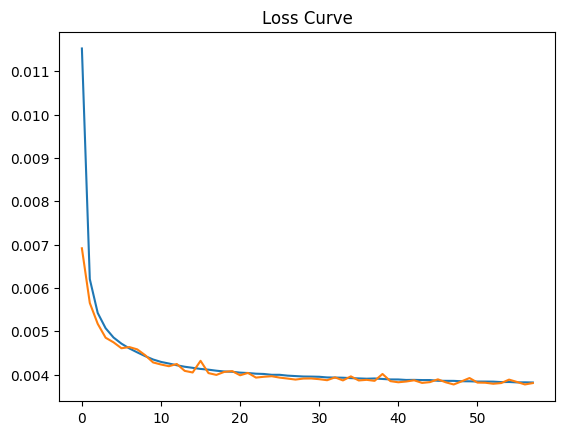

In [24]:
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val_Loss')
plt.title("Loss Curve")
plt.show()

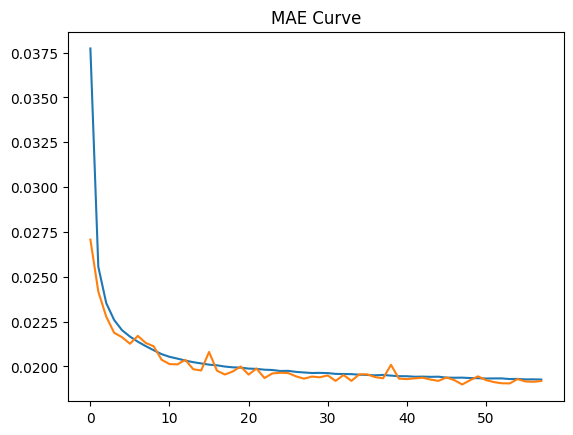

In [25]:
plt.plot(history.history['mae'], label='MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title("MAE Curve")
plt.show()

In [26]:
model.evaluate(X_test_noisy, X_test)

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0038 - mae: 0.0190


[0.0037735137157142162, 0.018994349986314774]

In [27]:
no_noise_img=model.predict(X_test_noisy)

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


C:\Users\maila\AppData\Local\Temp\ipykernel_28696\676186105.py:9: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\676186105.py:10: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
C:\Users\maila\AppData\Local\Temp\ipykernel_28696\676186105.py:11: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


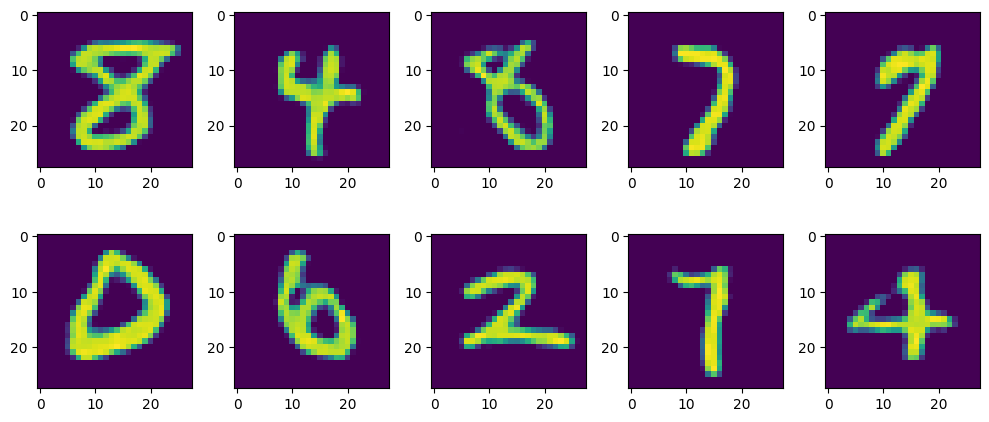

In [28]:
start=0
fig, axs=plt.subplots(2, 5, figsize=(10, 10))
for i in range(2):
  for j in range(5):
    dummy=no_noise_img[start].reshape(28, 28)
    axs[i][j].imshow(dummy)
    start += 1
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()
fig.tight_layout()

plt.show()
## Model Predicted Output

In [29]:
model.save('Denoise_MNIST_autoencoder.keras')